# TIME SERIES ANALYSIS

## IMPORTS

In [18]:
# Dataset import
from ucimlrepo import fetch_ucirepo

# General imports
import numpy as np
import pandas as pd 

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns

#Descomposition import
from statsmodels.tsa.seasonal import STL

## DATASET LOADING

In [3]:
# fetch dataset 
bike_sharing = fetch_ucirepo(id=275) 
  
# original df 
df = bike_sharing.data.original

df['datetime'] = pd.to_datetime(df['dteday'])

df.set_index('datetime', inplace=True)
df.sort_index(inplace=True)

# variable information 
print(bike_sharing.variables)

print(df.head())

          name     role         type demographic  \
0      instant       ID      Integer        None   
1       dteday  Feature         Date        None   
2       season  Feature  Categorical        None   
3           yr  Feature  Categorical        None   
4         mnth  Feature  Categorical        None   
5           hr  Feature  Categorical        None   
6      holiday  Feature       Binary        None   
7      weekday  Feature  Categorical        None   
8   workingday  Feature       Binary        None   
9   weathersit  Feature  Categorical        None   
10        temp  Feature   Continuous        None   
11       atemp  Feature   Continuous        None   
12         hum  Feature   Continuous        None   
13   windspeed  Feature   Continuous        None   
14      casual    Other      Integer        None   
15  registered    Other      Integer        None   
16         cnt   Target      Integer        None   

                                          description units mis

## ANALYSIS

### Time Series Visualization

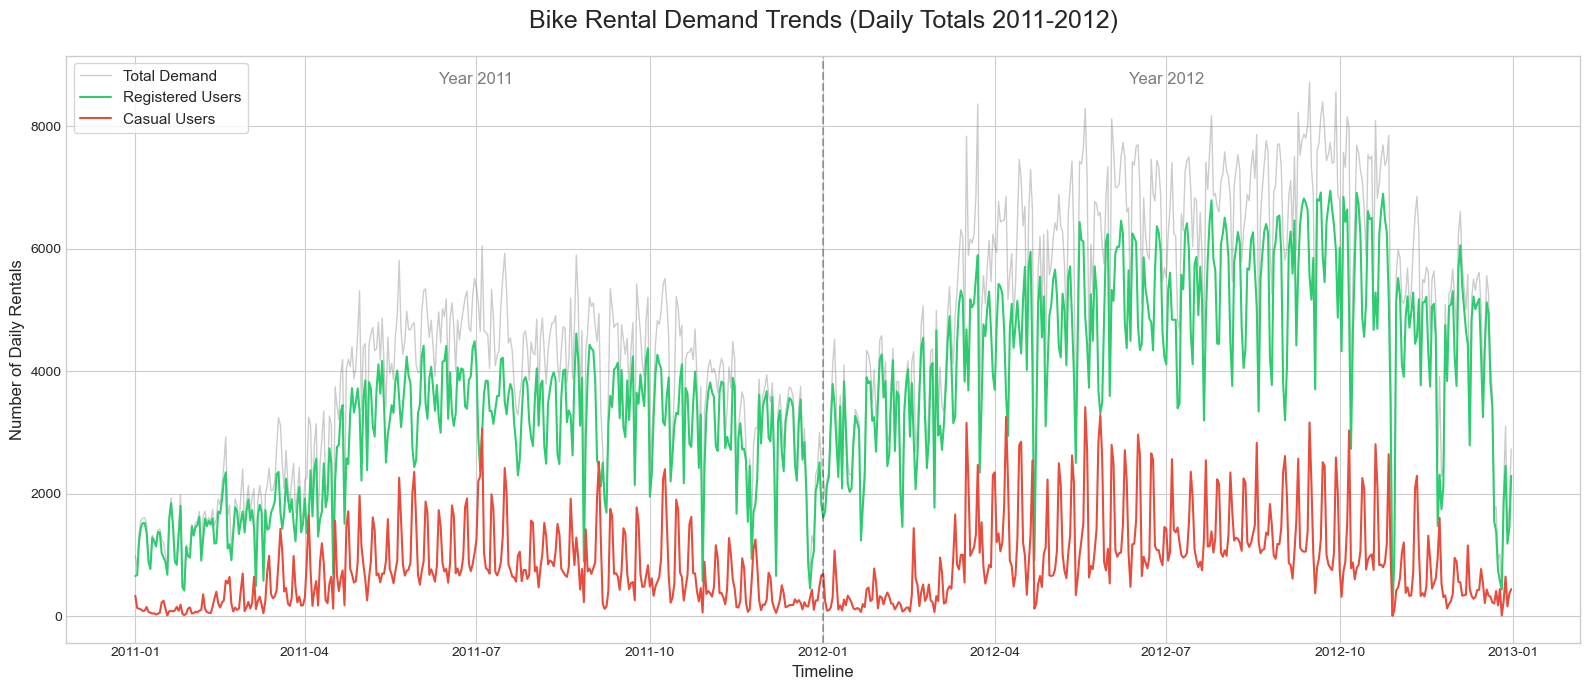

In [8]:
df_daily = df[['cnt', 'registered', 'casual']].resample('D').sum()

# 2. Plotting
plt.style.use('seaborn-v0_8-whitegrid') # Clean background
fig, ax = plt.subplots(figsize=(16, 7))

# We use thinner lines and specific colors
ax.plot(df_daily.index, df_daily['cnt'], label='Total Demand', color='gray', alpha=0.4, linewidth=1)
ax.plot(df_daily.index, df_daily['registered'], label='Registered Users', color='#2ecc71', linewidth=1.5)
ax.plot(df_daily.index, df_daily['casual'], label='Casual Users', color='#e74c3c', linewidth=1.5)

# Titles and Labels in English
ax.set_title('Bike Rental Demand Trends (Daily Totals 2011-2012)', fontsize=18, pad=20)
ax.set_xlabel('Timeline', fontsize=12)
ax.set_ylabel('Number of Daily Rentals', fontsize=12)
ax.legend(loc='upper left', frameon=True, fontsize=11)

# Clean X-axis (optional: adds a vertical line for the year change)
ax.axvline(pd.Timestamp('2012-01-01'), color='black', linestyle='--', alpha=0.3)
ax.text(pd.Timestamp('2011-07-01'), ax.get_ylim()[1]*0.95, 'Year 2011', fontsize=12, ha='center', alpha=0.6)
ax.text(pd.Timestamp('2012-07-01'), ax.get_ylim()[1]*0.95, 'Year 2012', fontsize=12, ha='center', alpha=0.6)

plt.tight_layout()
plt.show()

### Seasonality Analysis

#### Annual Seasonality

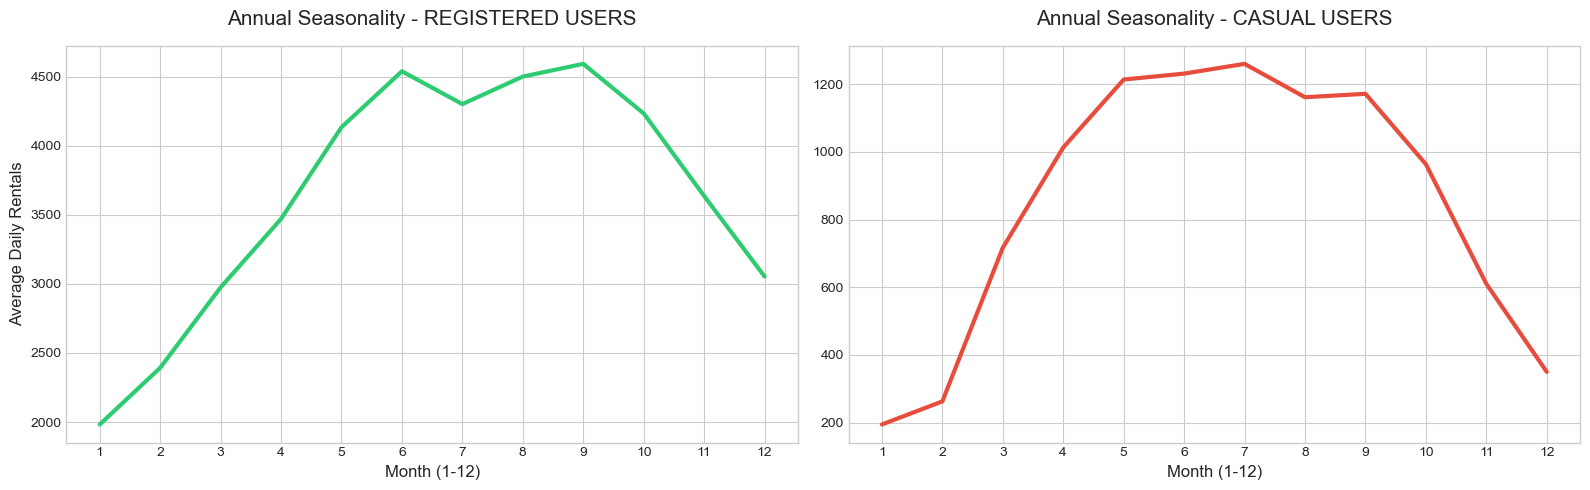

In [16]:
daily_totals = df.groupby(['dteday', 'mnth'])[['registered', 'casual']].sum().reset_index()

# 2. Calculamos el promedio de esos alquileres diarios para cada mes (1-12)
avg_monthly = daily_totals.groupby('mnth')[['registered', 'casual']].mean()

# 3. Gráfico (Líneas limpias sin marcadores)
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Subplot 1: REGISTERED ---
axes[0].plot(avg_monthly.index, avg_monthly['registered'], color='#2ecc71', linewidth=3)
axes[0].set_title('Annual Seasonality - REGISTERED USERS', fontsize=15, pad=15)
axes[0].set_xlabel('Month (1-12)', fontsize=12)
axes[0].set_ylabel('Average Daily Rentals', fontsize=12)
axes[0].set_xticks(range(1, 13)) # Meses del 1 al 12

# --- Subplot 2: CASUAL ---
axes[1].plot(avg_monthly.index, avg_monthly['casual'], color='#e74c3c', linewidth=3)
axes[1].set_title('Annual Seasonality - CASUAL USERS', fontsize=15, pad=15)
axes[1].set_xlabel('Month (1-12)', fontsize=12)
axes[1].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

#### Weekly Seasonality

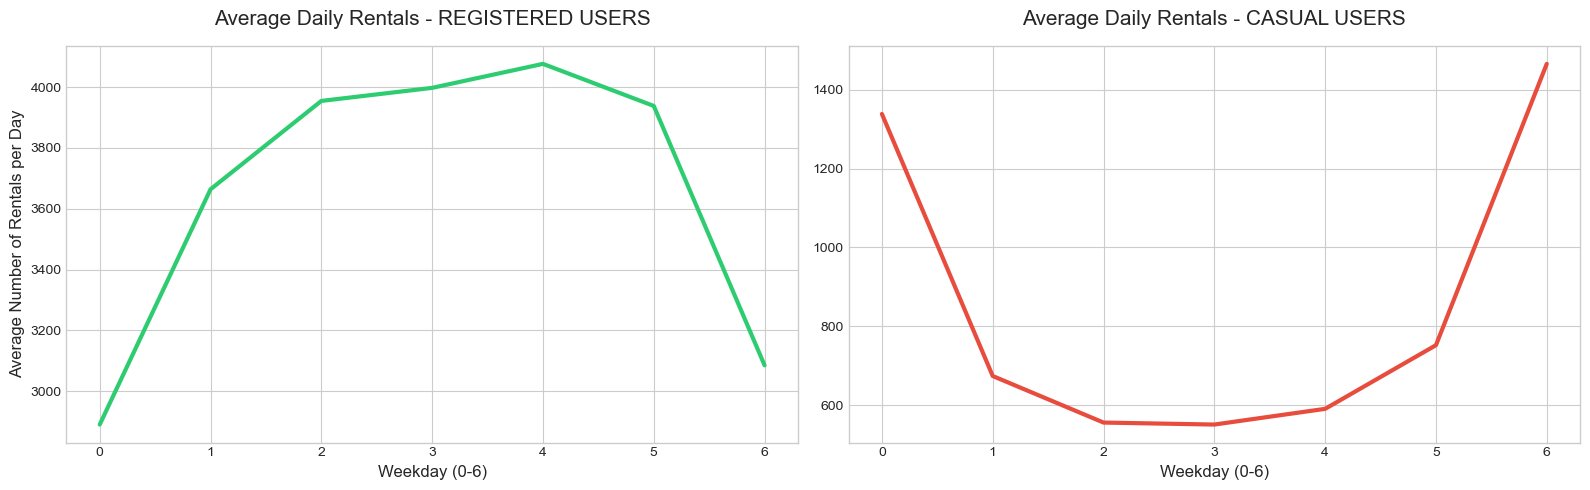

In [14]:
aily_totals = df.groupby(['dteday', 'weekday'])[['registered', 'casual']].sum().reset_index()

# 2. Calculamos el promedio para cada día de la semana (0-6)
avg_weekday = daily_totals.groupby('weekday')[['registered', 'casual']].mean()

# 3. Gráfico (Líneas limpias)
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Subplot 1: REGISTERED ---
axes[0].plot(avg_weekday.index, avg_weekday['registered'], color='#2ecc71', linewidth=3)
axes[0].set_title('Average Daily Rentals - REGISTERED USERS', fontsize=15, pad=15)
axes[0].set_xlabel('Weekday (0-6)', fontsize=12)
axes[0].set_ylabel('Average Number of Rentals per Day', fontsize=12)
axes[0].set_xticks(range(0, 7))

# --- Subplot 2: CASUAL ---
axes[1].plot(avg_weekday.index, avg_weekday['casual'], color='#e74c3c', linewidth=3)
axes[1].set_title('Average Daily Rentals - CASUAL USERS', fontsize=15, pad=15)
axes[1].set_xlabel('Weekday (0-6)', fontsize=12)
axes[1].set_xticks(range(0, 7))

plt.tight_layout()
plt.show()

#### Hourly Seasonality

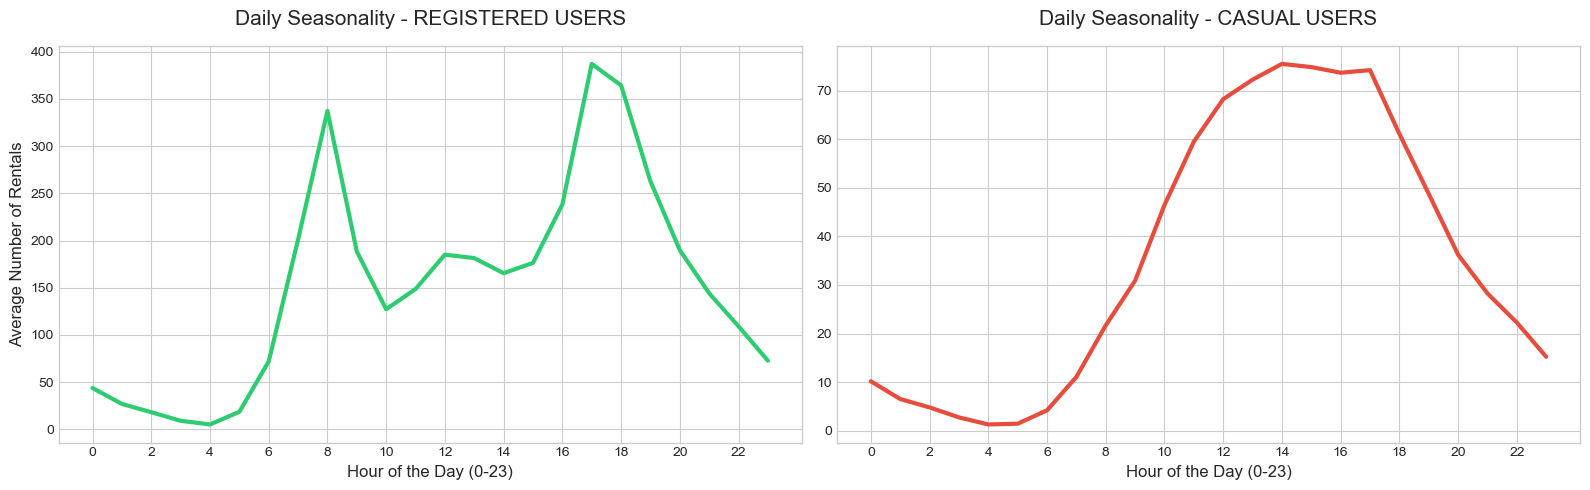

In [15]:
# 1. Agrupamos por la columna de la hora ('hr') y calculamos el promedio
avg_hourly = df.groupby('hr')[['registered', 'casual']].mean()

# 2. Gráfico (Líneas limpias)
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Subplot 1: REGISTERED ---
# Aumentamos un poco el linewidth a 3 para que la línea destaque más al no tener puntos
axes[0].plot(avg_hourly.index, avg_hourly['registered'], color='#2ecc71', linewidth=3)
axes[0].set_title('Daily Seasonality - REGISTERED USERS', fontsize=15, pad=15)
axes[0].set_xlabel('Hour of the Day (0-23)', fontsize=12)
axes[0].set_ylabel('Average Number of Rentals', fontsize=12)
axes[0].set_xticks(range(0, 24, 2))

# --- Subplot 2: CASUAL ---
axes[1].plot(avg_hourly.index, avg_hourly['casual'], color='#e74c3c', linewidth=3)
axes[1].set_title('Daily Seasonality - CASUAL USERS', fontsize=15, pad=15)
axes[1].set_xlabel('Hour of the Day (0-23)', fontsize=12)
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

### Descomposition

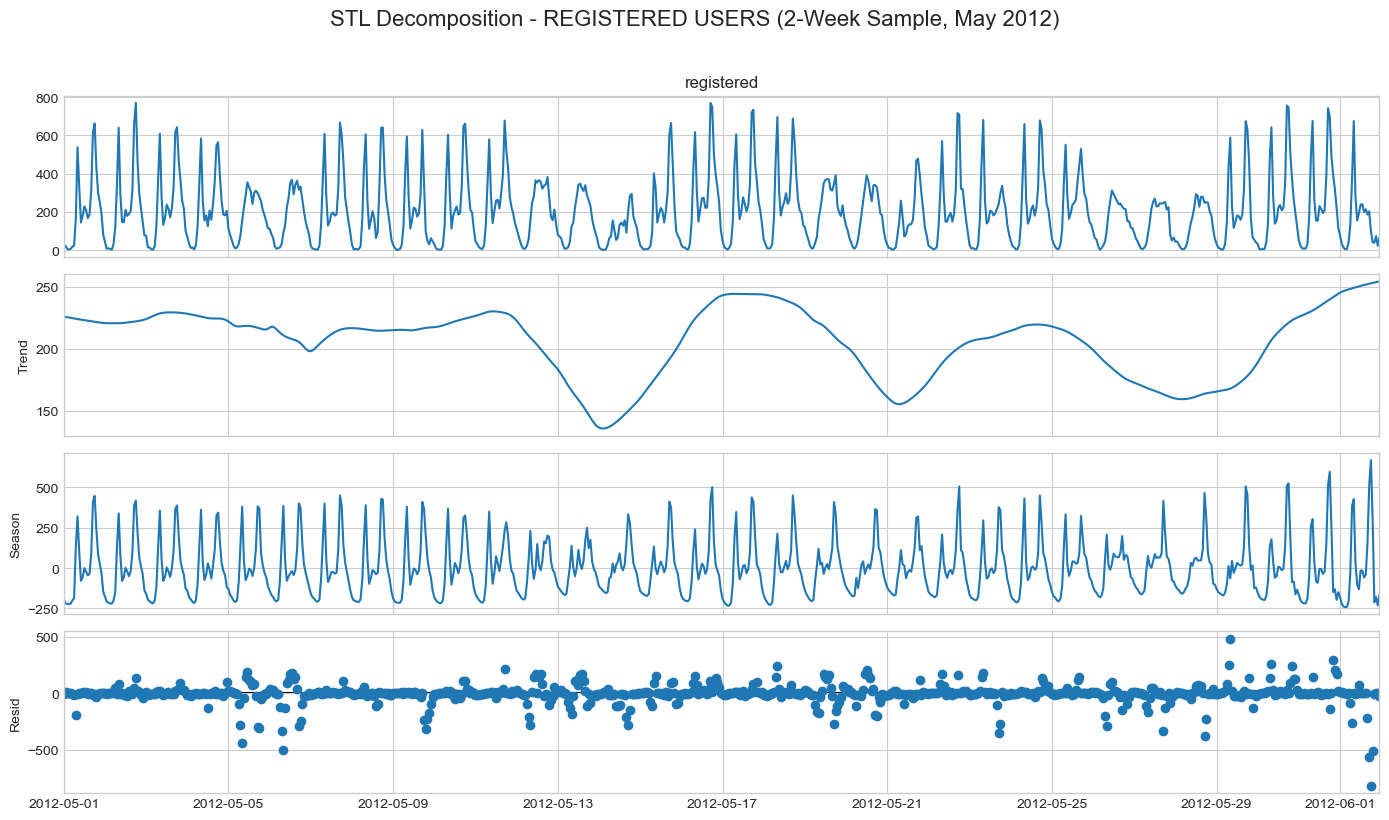

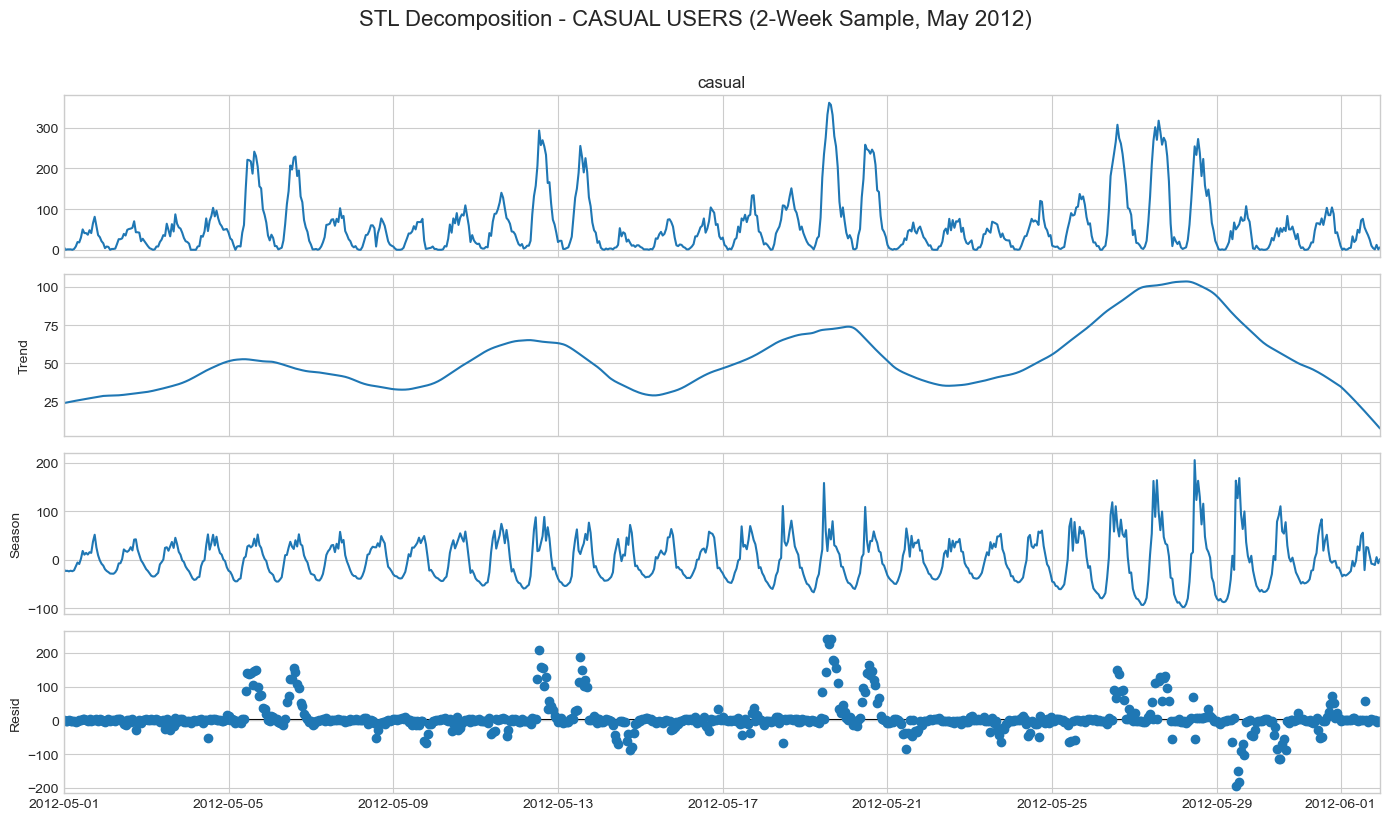

In [23]:
# 1. Seleccionamos una muestra representativa (2 semanas) para que el gráfico sea legible
# Asegúrate de que tu DataFrame tiene el índice de tipo datetime configurado
subset = df.loc['2012-05-01':'2012-06-01']

# 2. Aplicamos STL a ambas series
# period=24 indica la frecuencia diaria (24 horas)
# robust=True ayuda a que los outliers (ej. un día de lluvia fuerte) vayan a los residuos y no rompan la tendencia
stl_reg = STL(subset['registered'], period=24, robust=True).fit()
stl_cas = STL(subset['casual'], period=24, robust=True).fit()

# --- 3. Gráfico de Descomposición para REGISTERED ---
# STL tiene su propio método .plot() que genera los 4 paneles automáticamente
plt.style.use('seaborn-v0_8-whitegrid')
fig_reg = stl_reg.plot()
fig_reg.set_size_inches(14, 8)
fig_reg.suptitle('STL Decomposition - REGISTERED USERS (2-Week Sample, May 2012)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# --- 4. Gráfico de Descomposición para CASUAL ---
fig_cas = stl_cas.plot()
fig_cas.set_size_inches(14, 8)
fig_cas.suptitle('STL Decomposition - CASUAL USERS (2-Week Sample, May 2012)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()